<p align="center">
  <img src="https://raw.githubusercontent.com/paulmunozpauta/Hidrology_Course/main/Static/Imgs/UdeC_color_horizontal.jpg" width="500">
</p>
<p align="center"><b style="font-size:28px;">Facultad de Ingeniería Agrícola</b></p>
<p align="center"><b style="font-size:28px;">Curso de Hidrología</b></p>
<hr>
<p align="center"><b style="font-size:28px;">Contacto</b></p>
<p align="center">
  paulmunoz@udec.cl<br>
  https://paulmunoz.com
</p>

# Delimitación de una cuenca hidrográfica

## Objetivo
Delimitar una cuenca hidrográfica a partir de un Modelo Digital de Elevación (DEM) y un punto de salida.

---

## Conceptos clave

### ¿Qué es una cuenca hidrográfica?
Una cuenca hidrográfica es el área donde toda el agua escurre hacia un mismo punto de salida.

### ¿Qué es un DEM?
Un DEM (Digital Elevation Model) es una grilla donde cada píxel representa la elevación del terreno.

Es útil para:
- analizar flujo de agua  
- delimitar cuencas  
- calcular pendientes  

# Recurso recomendado:

Mapa interactivo permite rastrear el trayecto de una gota de agua hasta el mar

https://river-runner-global.samlearner.com/

## Antes de empezar

En este curso utilizamos materiales (código y datos) almacenados en un repositorio de GitHub.

### ¿Qué es un repositorio?
Un repositorio es una carpeta en línea que contiene archivos de un proyecto, como:
- código
- datos
- notebooks
- documentación

### ¿Qué significa "clonar un repositorio"?
Clonar un repositorio significa **descargar una copia completa de ese proyecto desde internet a nuestro entorno de trabajo (Google Colab)**.

Esto nos permite:
- acceder a los datos del curso  
- ejecutar los notebooks  
- modificar el código  

En este caso, vamos a clonar el repositorio del curso de hidrología.



In [1]:
# Clonar el repositorio desde GitHub
!git clone -- https://github.com/paulmunozpauta/Hidrology_Course

Cloning into 'Hidrology_Course'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 73 (delta 14), reused 11 (delta 3), pack-reused 38 (from 1)
Receiving objects: 100% (73/73), 60.84 MiB | 18.74 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Updating files: 100% (12/12), done.


Después de ejecutar la celda anterior, se crea una carpeta en nuestro entorno llamada:

**Hidrology_Course**

Esta carpeta contiene todos los archivos del curso.

Ahora debemos entrar a esa carpeta para trabajar con los datos.

In [2]:
ls

Hidrology_Course/  sample_data/


# Entrar a la carpeta del repositorio
%cd Hidrology_Course
!ls




In [3]:
# Entrar a la carpeta del repositorio
%cd Hidrology_Course
!ls

/content/Hidrology_Course
01_Delimitacion_cuenca.ipynb  Data  README.md  Static


Ahora estamos dentro del repositorio del curso.

Aquí podemos encontrar:

- notebooks (.ipynb)
- carpeta Data/ con los datos
- archivos de apoyo

En este notebook trabajaremos con datos de la Región de Ñuble.

## Instalación de librerías

En esta sección instalamos las librerías necesarias.

### Librerías principales:
- rasterio → manejo de datos raster  
- geopandas → datos vectoriales  
- shapely → geometría  
- pysheds → análisis hidrológico  
- leafmap → mapas interactivos  

# Delimitación de cuenca hidrográfica

Este notebook permite delimitar una cuenca hidrográfica a partir de:

- un DEM (`dem.tif`)
- un punto de salida definido con coordenadas `lon/lat`

Está pensado para ejecutarse en **Google Colab** con librerías comunes y código simple, claro y bien comentado.


In [4]:
# Instalar librerías necesarias
!pip -q install leafmap pysheds rasterio geopandas shapely

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 666.8/666.8 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.0 MB/s eta 0:00:00


In [5]:
# Importar librerías
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape
import geopandas as gpd
from pysheds.grid import Grid
import leafmap.foliumap as leafmap
from rasterio.plot import show
from rasterio.enums import Resampling
from rasterio.warp import transform
from rasterio.plot import show
from shapely.geometry import Point
from matplotlib.colors import LinearSegmentedColormap

## Visualización del área de estudio

Este mapa sirve para ubicar la zona y elegir el punto de salida.


In [6]:
# Crear mapa base
m = leafmap.Map(center=[-36.59, -72.08], zoom=7)
m.add_basemap("OpenTopoMap")
m

## Cargar el DEM
El DEM es la base del análisis hidrológico.
Revisamos:
- resolución  
- dimensiones  
- sistema de coordenadas


### DEM oficial Hidrografía Chile (DGA)
https://lineasdebasepublicas.mma.gob.cl/datos_abiertos/dataset/hidrosfera/resource/7776d37b-8a9f-4bf9-be75-006b40af0b1b

In [7]:
dem_path = "Data/Ñuble/REGION_NUBLE_1.jp2"

with rasterio.open(dem_path) as src:
    print("Resolución:", src.res)
    print("Dimensiones:", src.width, "x", src.height)
    print("CRS:", src.crs)

Resolución: (0.00011559404618781494, 0.00011559404618781474)
Dimensiones: 18547 x 12783
CRS: GEOGCS["GCS_SIRGAS_Chile",DATUM["SIRGAS-Chile",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1064"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]


## Reducir resolución del DEM

Para facilitar el procesamiento, creamos una versión más liviana.

Esto NO cambia el DEM original.

In [10]:
dem_lowres_path = "Data/Ñuble/dem_lowres.tif"
scale_factor = 8
with rasterio.open(dem_path) as src:
    data = src.read(
        1,
        out_shape=(int(src.height/scale_factor), int(src.width/scale_factor)),
        resampling=Resampling.average
    )

    transform_lowres = src.transform * src.transform.scale(
        (src.width / data.shape[1]),
        (src.height / data.shape[0])
    )

    profile = src.profile.copy()
    profile.update({
        "height": data.shape[0],
        "width": data.shape[1],
        "transform": transform_lowres
    })

    with rasterio.open(dem_lowres_path, "w", **profile) as dst:
        dst.write(data, 1)
    print("DEM lowres guardado en:", dem_lowres_path)

DEM lowres guardado en: Data/Ñuble/dem_lowres.tif


## Visualización inicial del área de estudio

Primera inspección para:

- reconocer la ubicación general de la cuenca,
- identificar ríos y relieve,
- escoger un punto de salida aproximado.




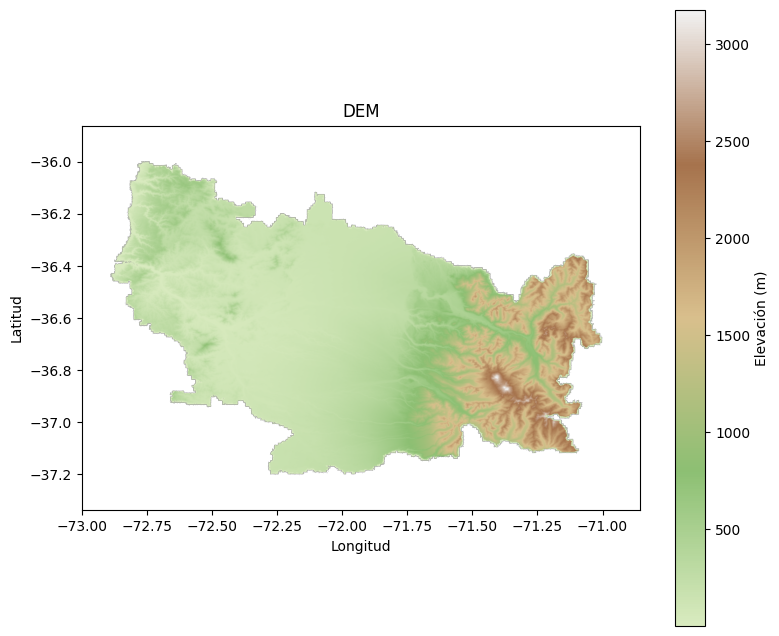

In [19]:
with rasterio.open(dem_lowres_path) as src:
    dem_plot = src.read(1).astype(float)
    bounds = src.bounds
    crs = src.crs

    if src.nodata is not None:
        dem_plot[dem_plot == src.nodata] = np.nan

dem_plot = np.ma.masked_where(np.isnan(dem_plot), dem_plot)

colors = [
    (0.85, 0.92, 0.75),
    (0.55, 0.75, 0.45),
    (0.85, 0.75, 0.55),
    (0.65, 0.45, 0.30),
    (0.95, 0.95, 0.95)
]

cmap = LinearSegmentedColormap.from_list("custom_terrain", colors, N=256)

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    dem_plot,
    cmap=cmap,
    extent=(bounds.left, bounds.right, bounds.bottom, bounds.top),
    origin="upper"
)

ax.set_title("DEM")

# Etiquetas según tipo de CRS
if crs.is_geographic:
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
else:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Elevación (m)")

plt.show()


## Visualización del DEM

En esta figura se representa el Modelo Digital de Elevación (DEM).

### ¿Qué observamos aquí?
Cada píxel del raster tiene un valor de elevación. Los colores permiten distinguir:

- zonas bajas,
- zonas medias,
- zonas altas.


## Preparación hidrológica del DEM

### Pasos:

1. Rellenar depresiones  
   Se eliminan huecos o "pozos" en el terreno donde el agua quedaría atrapada de forma artificial.

2. Resolver zonas planas  
   Se define hacia dónde fluye el agua en áreas completamente planas donde no hay pendiente clara.

3. Calcular dirección de flujo  
   Se determina hacia qué vecino fluye el agua en cada celda (la dirección de la pendiente).

4. Calcular acumulación  
   Se calcula cuánta agua llega a cada celda, sumando todo el flujo aguas arriba.


In [20]:
grid = Grid.from_raster(dem_lowres_path)
dem = grid.read_raster(dem_lowres_path)
print("Rellenando depresiones...")
dem_filled = grid.fill_depressions(dem)
print("Resolviendo zonas planas...")
dem_inflated = grid.resolve_flats(dem_filled)
print("Calculando dirección de flujo...")
fdir = grid.flowdir(dem_inflated)
print("Calculando acumulación...")
acc = grid.accumulation(fdir)
print("DEM listo para el análisis hidrológico.")

Rellenando depresiones...
Resolviendo zonas planas...
Calculando dirección de flujo...
Calculando acumulación...
DEM listo para el análisis hidrológico.


## Punto de salida

El punto de salida es donde el agua abandona la cuenca.

Debe ubicarse sobre un río.

In [21]:
# Coordenadas del punto de salida
approximate_lon = -71.75
approximate_lat = -36.6
point = Point(approximate_lon, approximate_lat)
print(f"Punto de salida: lon={approximate_lon}, lat={approximate_lat}")

Punto de salida: lon=-71.75, lat=-36.6


# Convertir el punto al CRS del DEM



In [22]:
from rasterio.warp import transform

with rasterio.open(dem_lowres_path) as src:
    x_out, y_out = transform("EPSG:4326", src.crs, [approximate_lon], [approximate_lat])
    x_out = x_out[0]
    y_out = y_out[0]

print("Punto en el CRS del DEM:")
print("x =", x_out)
print("y =", y_out)


Punto en el CRS del DEM:
x = -71.75
y = -36.6


## Ajuste del punto al río

Se ajusta el punto al píxel con mayor acumulación de flujo.

Esto mejora la delimitación de la cuenca.

In [39]:
import geopandas as gpd
import numpy as np
import rasterio
from shapely.geometry import Point
from shapely.ops import unary_union

def snap_to_main_river_with_min_acc(
    dem_path,
    river_shp_path,
    acc,
    x,
    y,
    min_strahler=7,
    search_radius=10
):
    rivers = gpd.read_file(river_shp_path)

    # filtrar ríos principales
    rivers = rivers[rivers["strahler_n"] >= min_strahler].copy()

    with rasterio.open(dem_path) as src:
        if rivers.crs != src.crs:
            rivers = rivers.to_crs(src.crs)

        # snap geométrico al río principal
        point = Point(x, y)
        river_union = unary_union(rivers.geometry)
        distance = river_union.project(point)
        snapped_point = river_union.interpolate(distance)

        river_x, river_y = snapped_point.x, snapped_point.y
        river_row, river_col = src.index(river_x, river_y)

        # ajuste local al pixel con mayor acumulación
        row_min = max(0, river_row - search_radius)
        row_max = min(acc.shape[0], river_row + search_radius + 1)
        col_min = max(0, river_col - search_radius)
        col_max = min(acc.shape[1], river_col + search_radius + 1)

        window_acc = acc[row_min:row_max, col_min:col_max]

        if window_acc.size == 0:
            raise ValueError("Ventana vacía.")

        local_idx = np.unravel_index(np.nanargmax(window_acc), window_acc.shape)

        snapped_row = row_min + local_idx[0]
        snapped_col = col_min + local_idx[1]

        snapped_x, snapped_y = src.xy(snapped_row, snapped_col)

    return snapped_x, snapped_y, snapped_row, snapped_col


river_shp_path = "Data/Cortado_clases/Hidrografía_XVI_Nuble.shp"
snapped_x, snapped_y, snapped_row, snapped_col = snap_to_main_river_with_min_acc(
    dem_lowres_path,
    river_shp_path,
    acc,
    x_out,
    y_out,
    min_strahler=7,
    search_radius=8
)

print("Nuevo outlet:")
print("x =", snapped_x)
print("y =", snapped_y)
print("acumulación =", acc[snapped_row, snapped_col])
print("porcentaje del máximo =", 100 * acc[snapped_row, snapped_col] / np.nanmax(acc))

Nuevo outlet:
x = -71.68234338291377
y = -36.513683237460086
acumulación = 213482.0
porcentaje del máximo = 19.50515765333626


## Visualización de la acumulación de flujo

La acumulación de flujo indica cuántas celdas aportan agua hacia cada píxel.

### Interpretación
- valores bajos: zonas de ladera o divisorias,
- valores altos: zonas donde se concentra el flujo, normalmente ríos o cauces.

Esta capa es muy útil para ajustar correctamente el punto de salida sobre la red de drenaje.

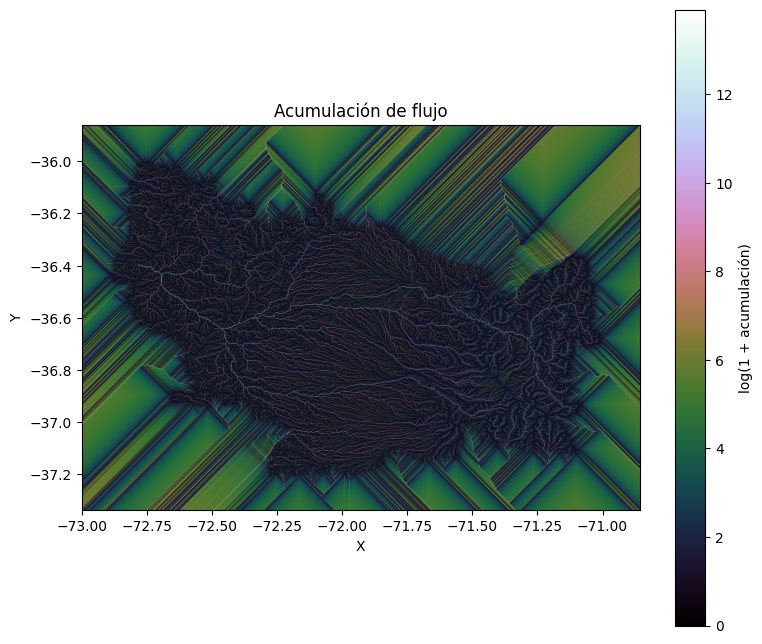

In [40]:
fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    np.log1p(acc),
    extent=grid.extent,
    cmap="cubehelix"
)

ax.set_title("Acumulación de flujo")
ax.set_xlabel("X")
ax.set_ylabel("Y")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log(1 + acumulación)")

plt.show()

## Comparación entre el punto aproximado y el punto ajustado

El punto ingresado manualmente puede no coincidir exactamente con el cauce.

Por eso se ajusta al píxel cercano con mayor acumulación de flujo.

### En la figura:
- punto rojo: punto aproximado ingresado por el usuario,
- punto amarillo: punto ajustado a la red de drenaje.

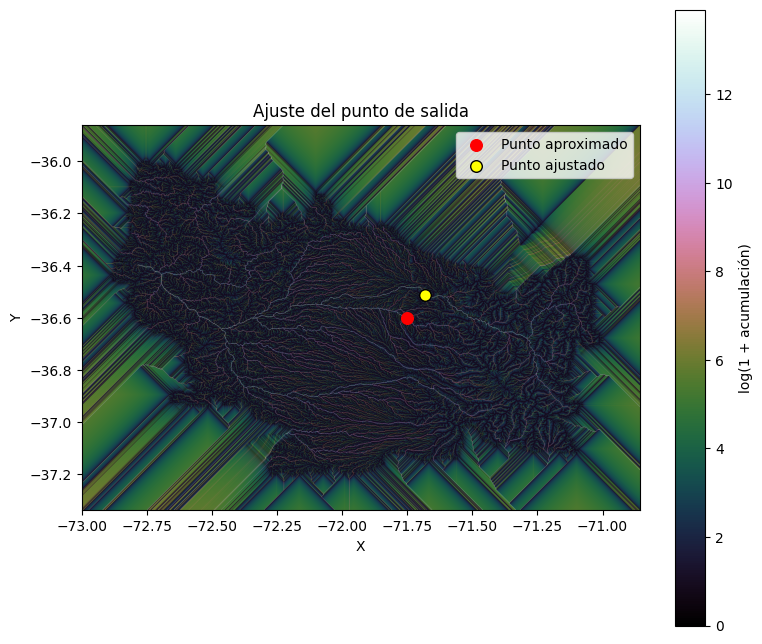

In [41]:
fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    np.log1p(acc),
    extent=grid.extent,
    cmap="cubehelix"
)

ax.scatter(x_out, y_out, s=70, c="red", label="Punto aproximado")
ax.scatter(snapped_x, snapped_y, s=70, c="yellow", edgecolor="black", label="Punto ajustado")

ax.set_title("Ajuste del punto de salida")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log(1 + acumulación)")

plt.show()

In [42]:
print("Acumulación en el outlet:", acc[snapped_row, snapped_col])
print("Acumulación máxima del DEM:", np.nanmax(acc))
print("Porcentaje respecto al máximo:",
      100 * acc[snapped_row, snapped_col] / np.nanmax(acc))

Acumulación en el outlet: 213482.0
Acumulación máxima del DEM: 1094490.0
Porcentaje respecto al máximo: 19.50515765333626


## Delimitación de la cuenca

In [43]:
catch = grid.catchment(
    x=snapped_col,
    y=snapped_row,
    fdir=fdir,
    xytype="index"
)

## Visualización de la cuenca delimitada

La delimitación genera una máscara raster donde se distinguen:

- celdas dentro de la cuenca,
- celdas fuera de la cuenca.

El punto rojo corresponde al exutorio o punto de salida.

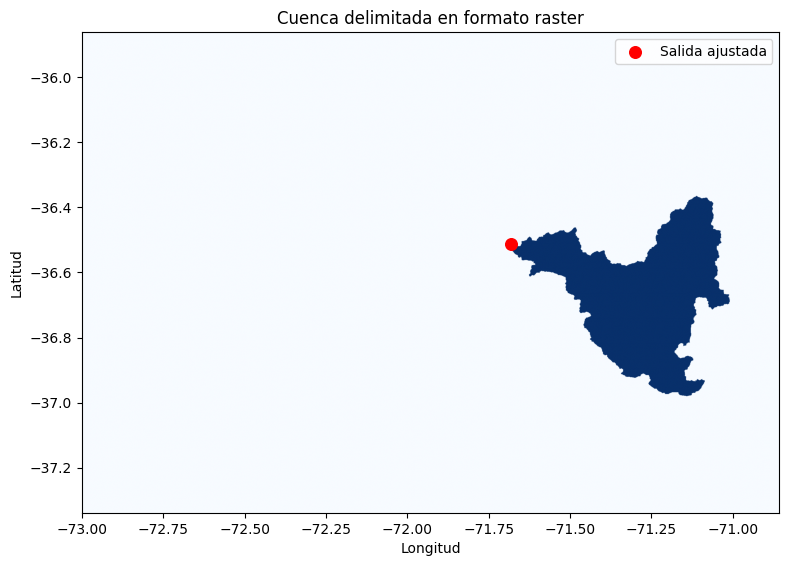

In [44]:
fig, ax = plt.subplots(figsize=(9, 8))

ax.imshow(catch, extent=grid.extent, cmap="Blues")
ax.scatter(snapped_x, snapped_y, s=70, c="red", label="Salida ajustada")

ax.set_title("Cuenca delimitada en formato raster")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend()

plt.show()

## Convertir a polígono

In [45]:
mask = catch.astype(np.uint8)

results = shapes(mask, mask=mask > 0, transform=grid.affine)
geoms = [shape(g) for g, v in results if v == 1]

basin = gpd.GeoDataFrame(geometry=geoms, crs=grid.crs).dissolve()

## Visualización del polígono de la cuenca

En esta figura se muestra el límite de la cuenca ya convertido a polígono.

Esto permite observar de forma más clara la forma de la cuenca y su relación con el punto de salida.

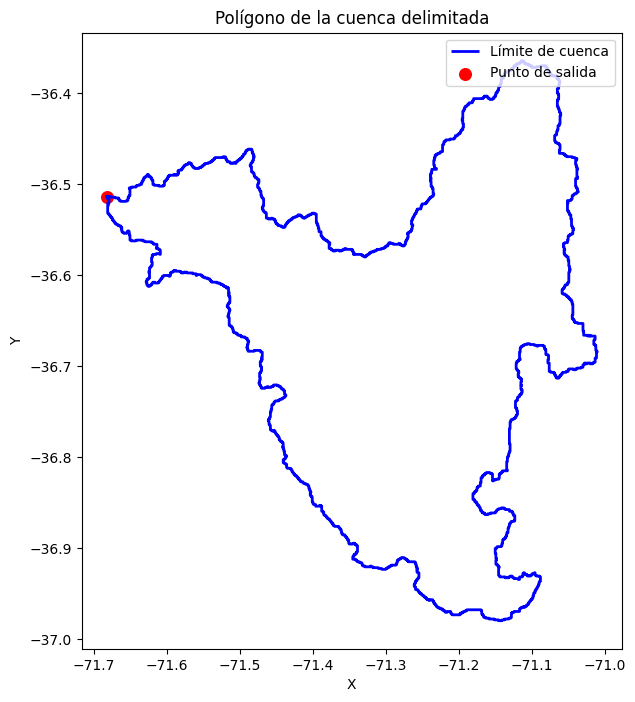

In [46]:
fig, ax = plt.subplots(figsize=(9, 8))

basin.boundary.plot(ax=ax, color="blue", linewidth=2, label="Límite de cuenca")
ax.scatter(snapped_x, snapped_y, s=70, c="red", label="Punto de salida")

ax.set_title("Polígono de la cuenca delimitada")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()

plt.show()

## Superposición del polígono sobre el DEM

Esta visualización permite relacionar la forma de la cuenca con el relieve.

Es útil para interpretar:

- divisorias de aguas,
- extensión de la cuenca,
- relación entre topografía y drenaje.

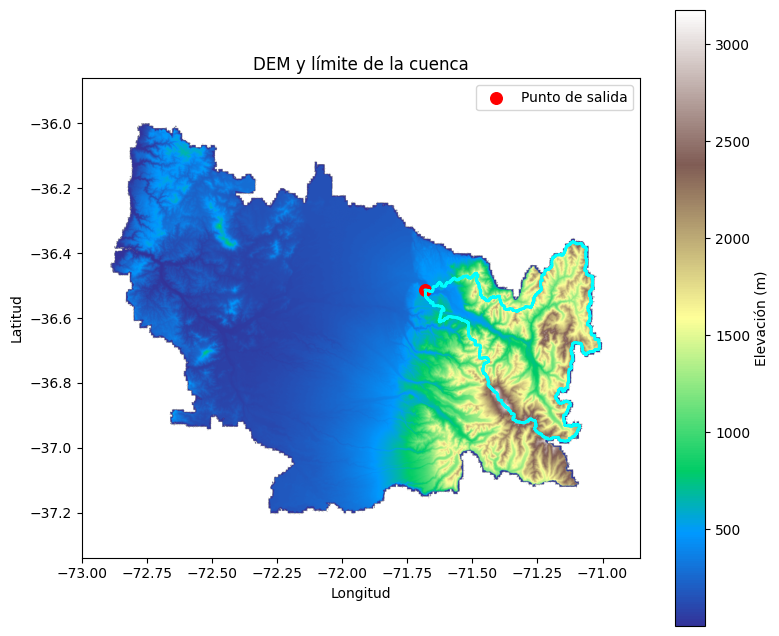

In [47]:
with rasterio.open(dem_lowres_path) as src:
    dem_plot = src.read(1).astype(float)

    if src.nodata is not None:
        dem_plot[dem_plot == src.nodata] = np.nan

    fig, ax = plt.subplots(figsize=(9, 8))

    im = ax.imshow(
        dem_plot,
        cmap="terrain",
        extent=(src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
    )

    basin.boundary.plot(ax=ax, color="cyan", linewidth=2)
    ax.scatter(snapped_x, snapped_y, s=70, c="red", label="Punto de salida")

    ax.set_title("DEM y límite de la cuenca")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.legend()

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Elevación (m)")

    plt.show()

## Área y perímetro

In [ ]:
basin_metric = basin.to_crs(basin.estimate_utm_crs())

area = basin_metric.area.iloc[0] / 1e6
perim = basin_metric.length.iloc[0] / 1000

print("Área km²:", area)
print("Perímetro km:", perim)

Área km²: 213.33925017636693
Perímetro km: 102.14341141533946


## Cálculo de atributos físicos de la cuenca

Una vez delimitada la cuenca, podemos calcular varios atributos físicos importantes.

### Ejemplos
- área,
- perímetro,
- elevación mínima, máxima y media,
- pendiente,
- longitud máxima aproximada,
- ancho medio aproximado,
- índices morfométricos.

Estos atributos son muy útiles para caracterizar hidrológicamente una cuenca.

In [ ]:
if basin.crs.is_geographic:
    basin_metric = basin.to_crs(basin_gdf.estimate_utm_crs())
else:
    basin_metric = basin.copy()

basin_geom = basin_metric.geometry.iloc[0]

area_m2 = basin_geom.area
area_km2 = area_m2 / 1e6

perimeter_m = basin_geom.length
perimeter_km = perimeter_m / 1000

print(f"Área: {area_km2:.2f} km²")
print(f"Perímetro: {perimeter_km:.2f} km")

Área: 213.34 km²
Perímetro: 102.14 km


## Tabla resumen de atributos físicos

La siguiente tabla resume los principales parámetros físicos de la cuenca.

Esta tabla puede exportarse a un archivo CSV para usarla posteriormente en informes, prácticas o análisis complementarios.

In [ ]:
basin_summary = pd.DataFrame({
    "Parámetro": [
        "Área",
        "Perímetro",
        "Elevación mínima",
        "Elevación máxima",
        "Elevación media",
        "Desviación estándar de elevación",
        "Pendiente media",
        "Pendiente mínima",
        "Pendiente máxima",
        "Longitud máxima aproximada",
        "Ancho medio aproximado",
        "Factor de forma",
        "Índice de compacidad",
        "Índice de circularidad"
    ],
    "Valor": [
        area_km2,
        perimeter_km,
        elev_min,
        elev_max,
        elev_mean,
        elev_std,
        slope_mean,
        slope_min,
        slope_max,
        length_max_km,
        mean_width_km,
        form_factor,
        gravelius,
        circularity
    ],
    "Unidad": [
        "km²",
        "km",
        "m",
        "m",
        "m",
        "m",
        "grados",
        "grados",
        "grados",
        "km",
        "km",
        "-",
        "-",
        "-"
    ]
})

basin_summary

,Parámetro,Valor,Unidad
0,Área,213.339250,km²
1,Perímetro,102.143411,km
2,Elevación mínima,19.000000,m
3,Elevación máxima,3177.000000,m
4,Elevación media,683.839242,m
5,Desviación estándar de elevación,666.653900,m
6,Pendiente media,88.425747,grados
7,Pendiente mínima,0.000000,grados
8,Pendiente máxima,89.999940,grados
9,Longitud máxima aproximada,141.023210,km


In [ ]:
output_csv = "Data/Ñuble/Caracteristicas_cuenca.csv"
basin_summary.to_csv(output_csv, index=False)
print("Tabla de atributos guardada en:", output_csv)

Tabla de atributos guardada en: Data/Ñuble/Caracteristicas_cuenca.csv


## Mapa final resumen

Finalmente, se presenta una visualización integrada con:

- el DEM,
- el límite de la cuenca,
- el punto de salida.

Este tipo de figura es útil para informes y presentaciones.

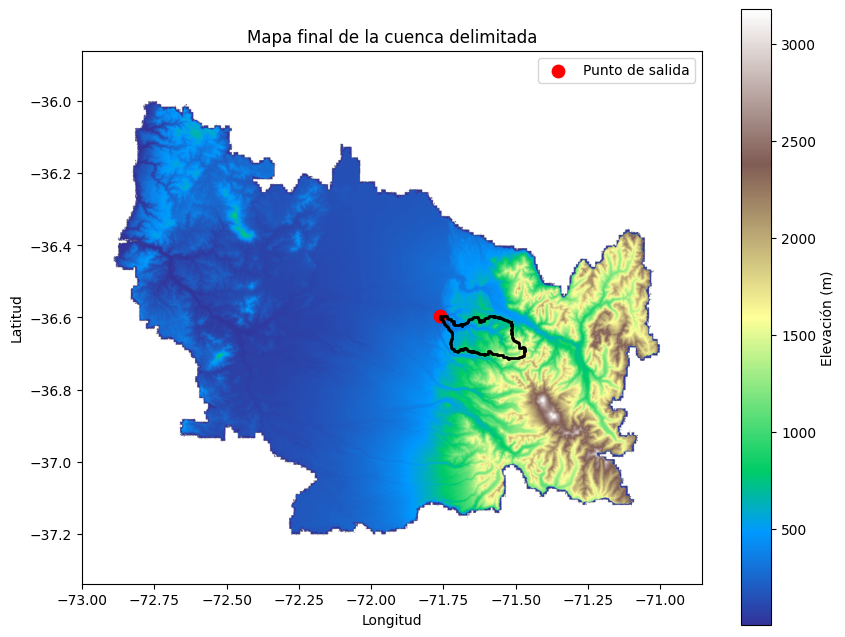

In [ ]:
with rasterio.open(dem_lowres_path) as src:
    dem_plot = src.read(1).astype(float)

    if src.nodata is not None:
        dem_plot[dem_plot == src.nodata] = np.nan

    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(
        dem_plot,
        cmap="terrain",
        extent=(src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
    )

    basin.boundary.plot(ax=ax, color="black", linewidth=2)
    ax.scatter(snapped_x, snapped_y, s=80, c="red", label="Punto de salida")

    ax.set_title("Mapa final de la cuenca delimitada")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.legend()

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Elevación (m)")

    plt.show()

## Conclusiones

En este ejercicio aprendimos a:

- trabajar con DEM  
- preparar datos hidrológicos  
- delimitar cuencas  
- calcular parámetros básicos  

Este flujo es fundamental en hidrología aplicada.